# **Amazon Review Sentiment Analysis: Predicting Star Ratings with Machine Learning**
###  _Report done by Ethan Eye and Abraham Maldonado_  [[github link]](https://github.com/Lilium-Github/CS345-Reviews-Project)

# About the Data



We used [this](https://amazon-reviews-2023.github.io/) dataset of over 500 million product reviews, gathered from Amazon across 30+ different product categories. The data spans reviews from 1990-2023, and also carries metadata related to the reviews in question; however, for the purposes of this topic, we will be focusing on the textual data itself. Additionally, as a concession made due to the raw size of the data, we only used certain categories for individual tests. This might lead to more accurate models overall, as certain descriptors (slow, soft, bulky) may be negative for some categories and positive for others. Learning the specifics of what traits are valuable in which category may be a crucial part of testing models.

# CountVectorizer and TF-IDF
The very first problem with text analysis is a simple one. From simple algorithms like the perceptron, all the way to more complex classification tools like SVM, vectors are used to determine in which category data falls. However, text is not so easily calculated and turned into weight values. For this, we used two separate tools provided by scikit-learn; CountVectorizer and TfidfVectorizer. Both of these tools create a matrix out of the words in the data, allowing classification tools to treat the text in training data as individual features, based on how many times they appear in a particular data entry. TfidfVectorizer is a more powerful version of CountVectorizer, as it also assigns words weights based on how often they appear in the dataset as a whole; the word “hazardous” may appear in more reviews than the word “of”, and as a result, it is given more weight by the vectorizer. For this reason, TF-IDF is used for this particular project. 

Additionally, TF-IDF comes with a feature to filter out stopwords such as "of" and "is" entirely, but the difference made by enabling it is negligible, at least with respect to the Naive Bayes model.

![alt text](image-3.png)

# What is VADER?
VADER (Valence Aware Dictionary and sEntiment Reasoner) is a freely-available tool for sentiment analysis. It is essentially a pre-trained dictionary of English words, each with a given sentiment value (positive or negative) associated with it. When applied to an existing piece of text, it returns four separate scores, those being positive sentiment, negative sentiment, neutral sentiment, (all scores between 0-1) and a fourth value representing a compound score, which is between -1 and 1 (with positive sentiment being closer to 1 and negative sentiment being closer to -1). We used it for our analysis in addition to the two tools above in order to convert sentiment into a calculable number that the classification models could actually work on.

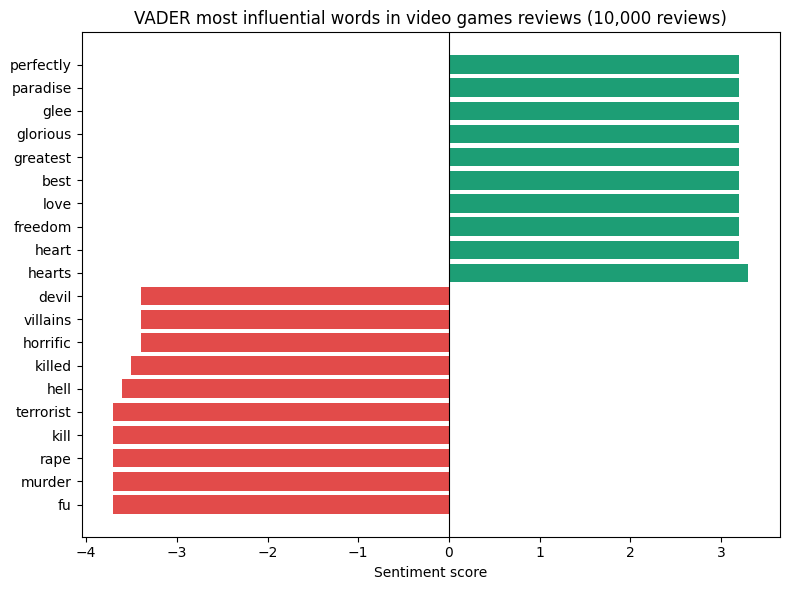

# Multi Class SVM

Support Vector Machine was our next model applied to the Amazon review dataset. Grid search and cross-validation were used to find the best hyperparameters. The results discussed in this section represent an early test run conducted to establish a baseline and identify areas for improvement, rather than the final optimised results. Using a small sample of 5,000 video game reviews and 500 TF-IDF features with an RBF kernel, the model severely overfit, achieving a training accuracy of 89% but only 46% accuracy on unseen data, as seen in the graph below. This was expected given the limited data and features, and served as a useful starting point for understanding how the model behaves before scaling up.

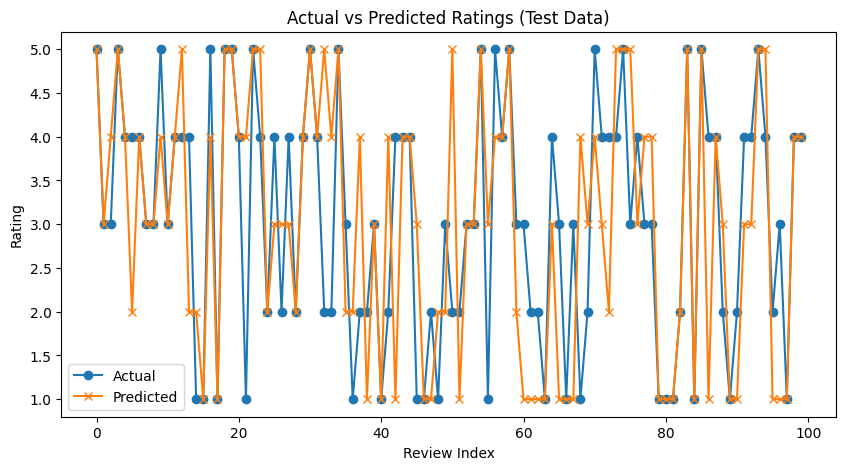

Subsequent runs addressed these issues by increasing the dataset size and number of TF-IDF features significantly. Using 100,000 reviews and 50,000 TF-IDF features with a linear kernel, the best parameters found were C=1, achieving a cross-validation accuracy of 71.01%, a training accuracy of 82.89%, and a test accuracy of 71.54% — a substantial improvement over the initial test run. However, the model took approximately 22 hours to train on this volume of data, making it impractical to replicate across all product categories. This highlighted one of the key limitations of SVM at scale: unlike neural networks, SVM cannot take advantage of GPU acceleration. This is because the algorithm relies on sequential optimisation rather than matrix multiplication, which means it cannot be efficiently parallelised across GPU cores the way neural network training can, causing training time to grow significantly with dataset size.

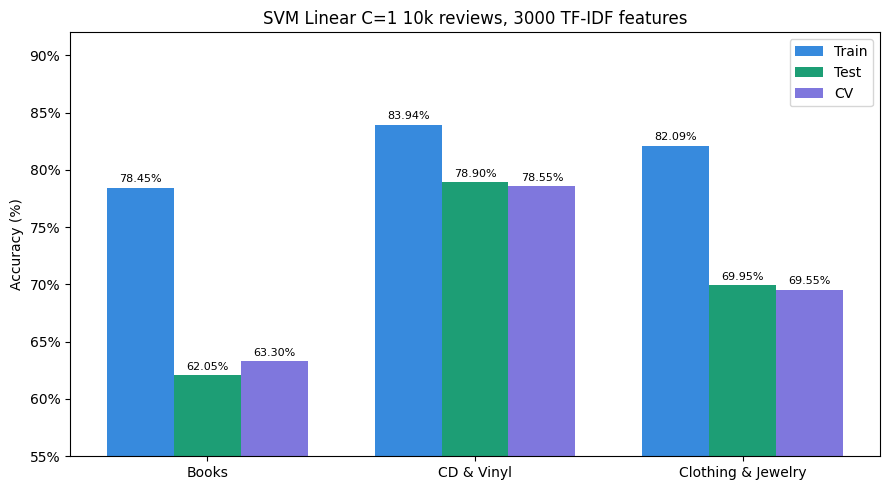

The SVM linear model with C=1 was tested across three product categories using 10,000 reviews and 3,000 TF-IDF features. CD & Vinyl performed the best with a test accuracy of 78.90%, likely due to the more polarised and expressive nature of music reviews. Clothing & Jewelry achieved a moderate test accuracy of 69.95%, while Books performed the worst at 62.05%. The large train/test gap in Books suggests the model struggled to generalise, possibly due to the more varied and complex language used in book reviews. These results suggest that review category has a significant impact on model performance, independent of the model or hyperparameters used.

# Naive Bayes
The Naive Bayes (specifically the Multinomial Naive Bayes, as there are 5 discrete categories to classify) was our choice of baseline algorithm for this project. By modeling the probability of a particular text entry belonging to any one of the given categories, it assigns it the class which it is most likely to belong to. However, despite its efficiency in both learning and predicting, it is an imperfect algorithm. The "Naive" in its name refers to the assumption made that every feature (that is, every word in a review) is completely independent from all others. This is not how language works, and thus some leaps in logic may be made, but the simplistic approach works well enough in this case. 

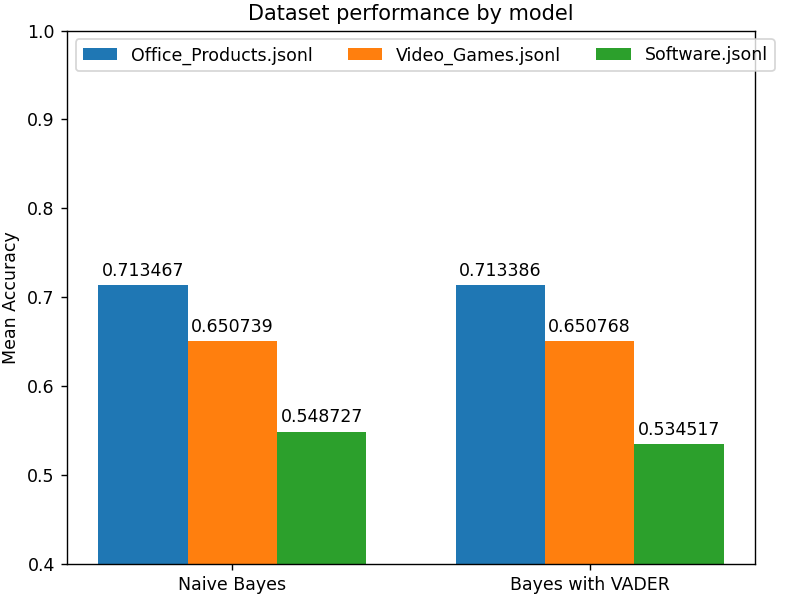

As the graph shows, the Naive Bayes classifier did not experience a substantial increase in accuracy when VADER was utilized as a supporting feature in the dataset. This may be for a number of reasons, such as the conflicting strategies of the two models (Naive Bayes is probabilistic, while VADER is deterministic), or violating Naive Bayes' expectation that every feature be independent (VADER's score is necessarily dependent on the words in a review). However, VADER did not end up affecting the overall accuracy of the model in either direction enough to conclusively label it helpful or not. The data suggests a slight skew towards worsening the accuracy overall, but the difference is so small that it cannot be made conclusive.

# Feedforward Neural Network


The preprocessing included the same process of filtering out data and analysing the sentiment values of words using TF-IDF and VADER. The feedforward neural network experimentation was done with the PyTorch library developed by Meta. PyTorch allowed the use of GPU processing power, enabling a larger number of reviews to be used for training data. Around 500,000 reviews were used to experiment with the feedforward model initially, however 100,000 reviews were used to speed up the grid search process for the video games, software, and office products datasets. The model showed similar results compared to Naive Bayes, in that software reviews were the hardest to predict at around 63% test accuracy. Video game reviews saw a solid 7% improvement in test accuracy, and the model performed surprisingly well on office product reviews, achieving a test accuracy of around 74%.

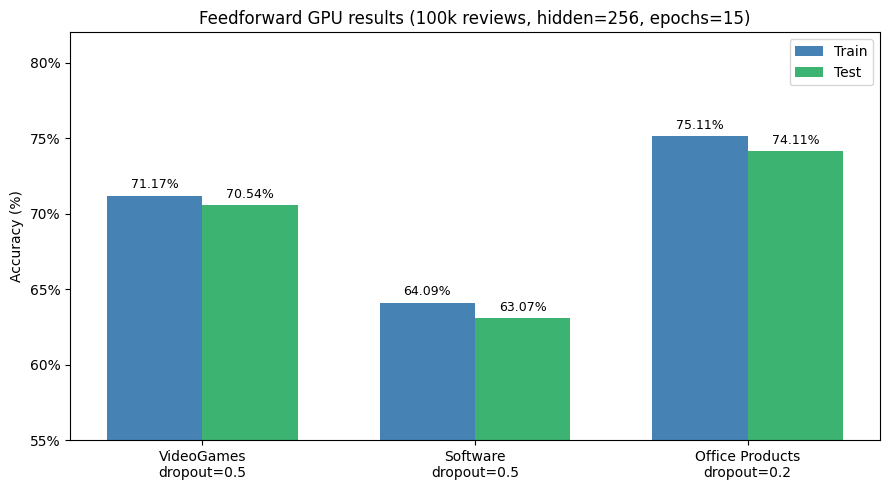